# Zika - Baseline Model

In [3]:
%reload_ext autoreload
%autoreload 2
from my_lib import *

## Imports

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error

In [5]:
location = "D"
df_z = pd.read_feather(f"data/zika_{location}.feather")
df_d = pd.read_feather(f"data/dengue_{location}.feather")
df_score = pd.read_feather(f"data/score_{location}.feather")
df_w = pd.read_feather(f"data/weather_{location}.feather")

In [6]:
target = "cases"

df_z['Month'] = df_z['EW_start_date'].dt.month
z_features = ['EW', 'EW_start_date', 'pop', 'Month']
df_z[z_features].head(1)

,EW,EW_start_date,pop,Month
1095,201601,2016-01-03,890480,1


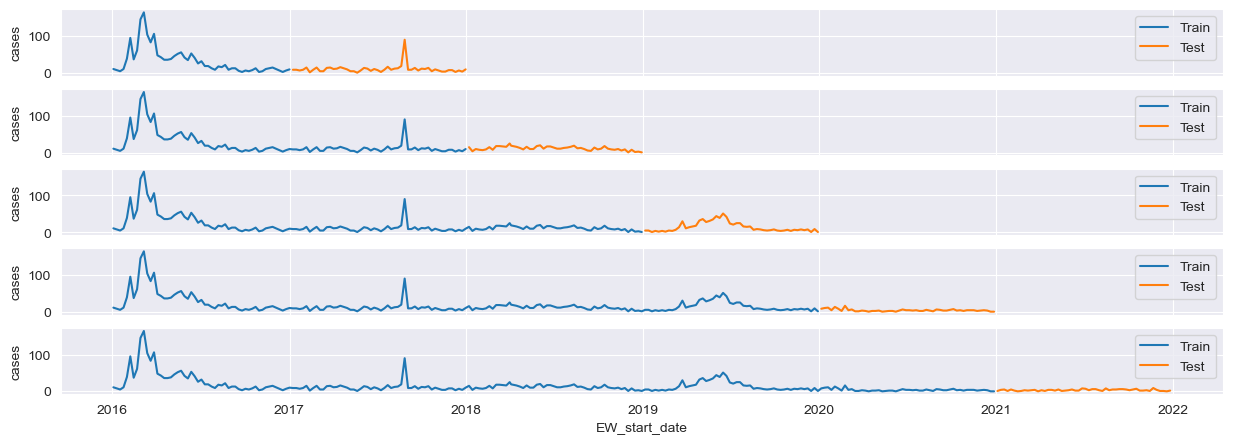

In [7]:
cv = TimeSeriesSplit(gap=0, n_splits=5, test_size=None)

fig, axs = plt.subplots(cv.n_splits, 1, figsize=(15, 5), sharex=True)

for (train_idx, test_idx), ax in zip(cv.split(df_z), axs):
    df_train = df_z.iloc[train_idx]
    df_test = df_z.iloc[test_idx]

    sns.lineplot(data=df_train, x="EW_start_date", y=target, ax=ax, label='Train')
    sns.lineplot(data=df_test, x="EW_start_date", y=target, ax=ax, label='Test')
    ax.legend()

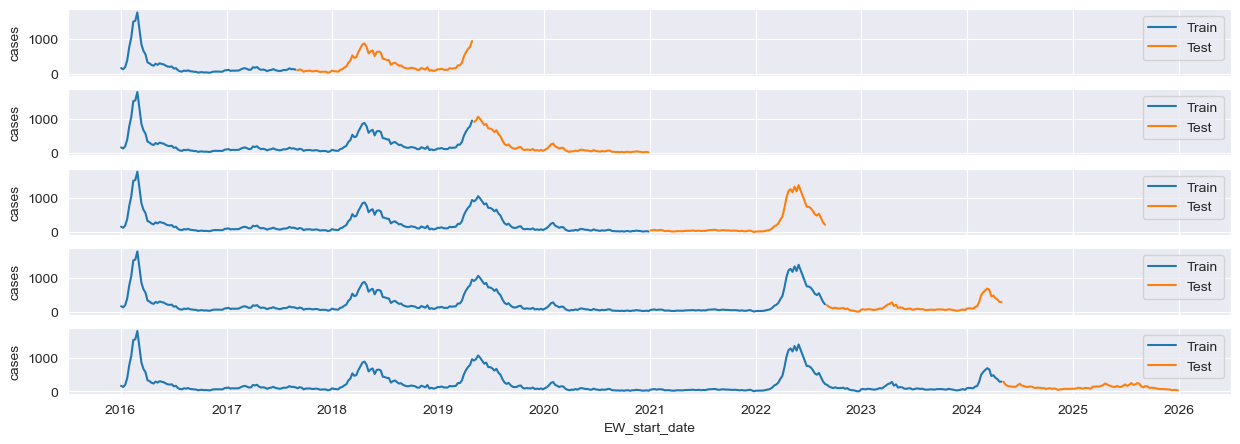

In [8]:
cv = TimeSeriesSplit(gap=0, n_splits=5, test_size=None)

fig, axs = plt.subplots(cv.n_splits, 1, figsize=(15, 5), sharex=True)

for (train_idx, test_idx), ax in zip(cv.split(df_d), axs):
    df_train = df_d.iloc[train_idx]
    df_test = df_d.iloc[test_idx]

    sns.lineplot(data=df_train, x="EW_start_date", y=target, ax=ax, label='Train')
    sns.lineplot(data=df_test, x="EW_start_date", y=target, ax=ax, label='Test')
    ax.legend()

In [9]:
df_z_tmp = df_z[z_features + [target]]
df_z_tmp.head(1)

,EW,EW_start_date,pop,Month,cases
1095,201601,2016-01-03,890480,1,11


In [10]:
df_d_tmp = df_d[['EW_start_date', 'cases']]
df_d_tmp = df_d_tmp.rename(columns={'cases': 'dengue'})
df_d_tmp.head(1)

,EW_start_date,dengue
1774,2016-01-03,162


In [11]:
df_w_tmp = df_w.copy()

for k in range(1,3):
    df_tmp = df_w_tmp.shift(k)
    df_tmp.EW_start_date = df_w_tmp.EW_start_date
    df_w_tmp = pd.merge(df_w_tmp, df_tmp, suffixes=('', f"_lag{k}"), on='EW_start_date', how='left')
df_w_tmp.head(5)

,EW_start_date,temperature_2m_min__mean,temperature_2m_min__std,precipitation_sum__mean,precipitation_sum__max,temperature_2m_min__mean_lag1,temperature_2m_min__std_lag1,precipitation_sum__mean_lag1,precipitation_sum__max_lag1,temperature_2m_min__mean_lag2,temperature_2m_min__std_lag2,precipitation_sum__mean_lag2,precipitation_sum__max_lag2,temperature_2m_min__mean_lag1_lag2,temperature_2m_min__std_lag1_lag2,precipitation_sum__mean_lag1_lag2,precipitation_sum__max_lag1_lag2
0,2015-01-04,23.688929,0.465347,4.257143,13.500001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-11,23.688929,0.463553,4.357143,9.100000,23.688929,0.465347,4.257143,13.500001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-18,23.381786,0.539069,5.628571,14.199999,23.688929,0.463553,4.357143,9.100000,23.688929,0.465347,4.257143,13.500001,NaN,NaN,NaN,NaN
3,2015-01-25,23.153215,0.603955,6.414286,14.200000,23.381786,0.539069,5.628571,14.199999,23.688929,0.463553,4.357143,9.100000,23.688929,0.465347,4.257143,13.500001
4,2015-02-01,24.003215,0.403850,7.071428,21.999998,23.153215,0.603955,6.414286,14.200000,23.381786,0.539069,5.628571,14.199999,23.688929,0.463553,4.357143,9.100000


In [12]:
df_model = df_z_tmp.copy()
df_model = pd.merge(df_model, df_d_tmp, on='EW_start_date', how='left')
df_model = pd.merge(df_model, df_w_tmp, on='EW_start_date', how='left')

cat_features = ['Month']
num_features = [f for f in df_model.columns[2:] if f not in cat_features and f != target]
features = num_features + cat_features

print(f"{cat_features = }")
print(f"{num_features = }")


cat_features = ['Month']
num_features = ['pop', 'dengue', 'temperature_2m_min__mean', 'temperature_2m_min__std', 'precipitation_sum__mean', 'precipitation_sum__max', 'temperature_2m_min__mean_lag1', 'temperature_2m_min__std_lag1', 'precipitation_sum__mean_lag1', 'precipitation_sum__max_lag1', 'temperature_2m_min__mean_lag2', 'temperature_2m_min__std_lag2', 'precipitation_sum__mean_lag2', 'precipitation_sum__max_lag2', 'temperature_2m_min__mean_lag1_lag2', 'temperature_2m_min__std_lag1_lag2', 'precipitation_sum__mean_lag1_lag2', 'precipitation_sum__max_lag1_lag2']


Fold 1
Fold 1 MAE: 19.6313
Fold 2
Fold 2 MAE: 22.2046
Fold 3
Fold 3 MAE: 15.6968
Fold 4
Fold 4 MAE: 8.6253
Fold 5
Fold 5 MAE: 5.6081


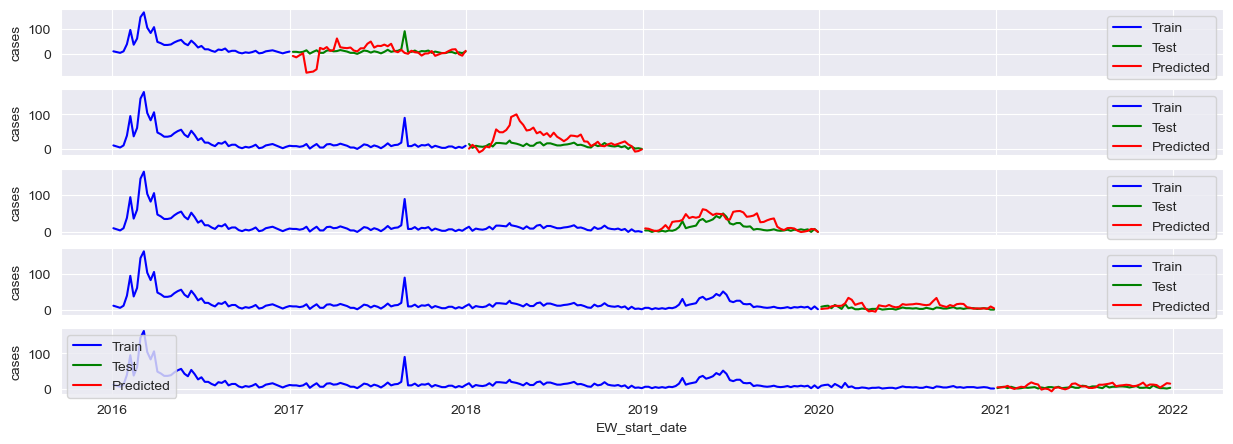

In [13]:
cv = TimeSeriesSplit(gap=0, n_splits=5, test_size=None)

fig, axs = plt.subplots(cv.n_splits, 1, figsize=(15, 5), sharex=True)

for k, (train_idx, test_idx) in enumerate(cv.split(df_model)):
    print(f"Fold {k+1}")
    df_train = df_model.iloc[train_idx]
    df_test = df_model.iloc[test_idx]

    ss = StandardScaler()
    X_train_num = ss.fit_transform(df_train[num_features])
    X_test_num = ss.transform(df_test[num_features])

    one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_train_cat = one.fit_transform(df_train[cat_features])
    X_test_cat = one.transform(df_test[cat_features])

    X_train = np.hstack([X_train_num, X_train_cat])
    X_test = np.hstack([X_test_num, X_test_cat])

    y_train = df_train[target].values
    y_test = df_test[target].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Fold {k+1} MAE: {mae:.4f}")

    df_tmp = df_test.copy()
    df_tmp['Predicted'] = y_pred
    
    sns.lineplot(data=df_train, x='EW_start_date', y=target, ax=axs[k], color='blue', label='Train')
    sns.lineplot(data=df_test, x='EW_start_date', y=target, ax=axs[k], color='green', label='Test')
    sns.lineplot(data=df_tmp, x='EW_start_date', y='Predicted', ax=axs[k], color='red', label='Predicted')

## Train Model on all data

In [16]:
def prepare_data(df_train, df_test, df_d, df_w, z_features, target, weather_lag=3, debug=False):
    
    y_train = df_train[target].values
    y_test = df_test[target].values if target in df_test.columns else None

    # zika
    df_train_tmp = df_train.copy()
    df_train_tmp['Month'] = df_train_tmp['EW_start_date'].dt.month
    df_train_tmp = df_train_tmp[z_features].copy()

    df_test_tmp = df_test.copy()
    df_test_tmp['Month'] = df_test_tmp['EW_start_date'].dt.month
    df_test_tmp = df_test_tmp[z_features].copy()

    # dengue
    df_d_tmp = df_d[['EW_start_date', 'cases']].copy()
    df_d_tmp.rename(columns={'cases': 'dengue'}, inplace=True)

    # weather
    df_w_tmp = df_w.copy()
    for k in range(1, weather_lag+1):
        df_tmp = df_w_tmp.shift(k)
        df_tmp.EW_start_date = df_w_tmp.EW_start_date
        df_w_tmp = pd.merge(df_w_tmp, df_tmp, suffixes=('', f'__lag{k}'), on='EW_start_date', how='left')

    # merge
    df_train_tmp = pd.merge(df_train_tmp, df_d_tmp, on='EW_start_date', how='left')
    df_train_tmp = pd.merge(df_train_tmp, df_w_tmp, on='EW_start_date', how='left')
    #
    df_test_tmp = pd.merge(df_test_tmp, df_d_tmp, on='EW_start_date', how='left')
    df_test_tmp = pd.merge(df_test_tmp, df_w_tmp, on='EW_start_date', how='left')

    # features
    cat_features = ['Month']
    num_features = [f for f in df_train_tmp.columns[2:] if f not in cat_features]
    if debug:
        print(f"{cat_features = }")
        print(f"{num_features = }")

    # preprocessing
    ss = StandardScaler()
    X_train_num = ss.fit_transform(df_train_tmp[num_features])
    X_test_num = ss.transform(df_test_tmp[num_features])

    one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_train_cat = one.fit_transform(df_train_tmp[cat_features])
    X_test_cat = one.transform(df_test_tmp[cat_features])

    X_train = np.hstack([X_train_num, X_train_cat])
    X_test = np.hstack([X_test_num, X_test_cat])

    return X_train, X_test, y_train, y_test


In [ ]:
for location in "ABCDEF":
    print(f"Location {location}")
    df_z = pd.read_feather(f"data/zika_{location}.feather")
    df_d = pd.read_feather(f"data/dengue_{location}.feather")
    df_s = pd.read_feather(f"data/score_{location}.feather")
    df_w = pd.read_feather(f"data/weather_{location}.feather")

    X_train, X_test, y_train, y_test = prepare_data(df_z, df_s, df_d, df_w, z_features, target, debug=True)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    df_s[target] = y_pred

    df_s.to_csv(f"output/baseline_model_{location}.csv", index=False)

Location A
cat_features = ['Month']
num_features = ['pop', 'dengue', 'temperature_2m_min__mean', 'temperature_2m_min__std', 'precipitation_sum__mean', 'precipitation_sum__max', 'temperature_2m_min__mean__lag1', 'temperature_2m_min__std__lag1', 'precipitation_sum__mean__lag1', 'precipitation_sum__max__lag1', 'temperature_2m_min__mean__lag2', 'temperature_2m_min__std__lag2', 'precipitation_sum__mean__lag2', 'precipitation_sum__max__lag2', 'temperature_2m_min__mean__lag1__lag2', 'temperature_2m_min__std__lag1__lag2', 'precipitation_sum__mean__lag1__lag2', 'precipitation_sum__max__lag1__lag2', 'temperature_2m_min__mean__lag3', 'temperature_2m_min__std__lag3', 'precipitation_sum__mean__lag3', 'precipitation_sum__max__lag3', 'temperature_2m_min__mean__lag1__lag3', 'temperature_2m_min__std__lag1__lag3', 'precipitation_sum__mean__lag1__lag3', 'precipitation_sum__max__lag1__lag3', 'temperature_2m_min__mean__lag2__lag3', 'temperature_2m_min__std__lag2__lag3', 'precipitation_sum__mean__lag2__lag3

In [ ]:
## Build Submission File

In [18]:
def make_sub_file(name="baseline_model"):
    dfs = [pd.read_csv(f"output/{name}_{location}.csv") for location in "ABCDEF"]
    df = pd.concat(dfs, ignore_index=True)
    df['ID'] = df['location'] + df['EW'].astype(str)
    df[['ID', 'cases']].to_csv(f"output/{name}_submission.csv", index=False)

make_sub_file()

FileNotFoundError: [Errno 2] No such file or directory: 'output/baseline_model_A.csv'